# COMSOL Geometry Preparation for a Linearized Transmon Eigenmode

::::{admonition} Required extras
:class: tip

This notebook needs the `comsol` extra:

```bash
uv add "qpdk[comsol]"          # or: pip install "qpdk[comsol]"
uv sync --extra comsol         # from a checkout of this repository
```

Installing the extra installs `MPh`, the Python client for COMSOL, and nothing
else. **It does not install COMSOL and it does not grant a license.** A COMSOL
installation and license are required to build the geometry; solving the RF
eigenfrequency problem also requires the RF Module. Google Colab has none of
them, so the modelling cells cannot run there.

See the {ref}`extras reference <notebook-extras>` for what each extra installs.
::::

```{warning}
**Scope of this notebook: geometry preparation only.**

`qpdk.simulation` provides two functions for COMSOL:

- {py:func}`~qpdk.simulation.comsol_layout.prepare_comsol_layout` extracts M1
  metal polygons (holes preserved) and a bounding box from a gdsfactory
  component. Called with `feed_ports=None` it returns no feed ports, which is
  the right choice for a qubit: the pads are not transmission-line ports.
- {py:func}`~qpdk.simulation.comsol.build_comsol_metal_model` imports those
  polygons into an MPh/COMSOL model as a 3D extruded solid.

Neither function adds a substrate, an air domain, materials, RF physics, a
Josephson inductance, a mesh, or a study. The saved `.mph` is an **unsolved
geometry project**. No eigenfrequency is computed here, and none is faked.
```

## What is being modelled

The device is a QPDK
{py:func}`~qpdk.cells.transmon.double_pad_transmon_with_bbox`: two rectangular
capacitor pads separated by a small gap, with a SQUID loop at the centre. The
pads dominate the capacitance $C$, and the SQUID supplies the Josephson energy
$E_J$, so the qubit transition frequency is set by $E_J$ and the charging
energy $E_C = e^2 / 2C$ {cite:p}`kochChargeinsensitiveQubitDesign2007a`.

In a real device the two pads are joined **only** through the Josephson
junction. The QPDK cell draws the SQUID's leads, tapers, and contact patches
on `JJ_AREA` and `JJ_PATCH`. Its oxide barriers are not zero-ohm metal shorts.
The electromagnetic field solver needs a *finite* effective inductance
between the pads; a direct metallic short would remove the transmon mode.

## Why bare pads are not enough

An RF eigenfrequency study on the isolated pads does **not** return the
transmon frequency. Without a substrate, an air domain, and a modelled
inductance at the junction, the solved eigenmodes are environment or package
modes of the metal geometry, not the qubit mode. A true linearized transmon
eigenmode needs all of the following.

1. **Substrate and air domains**: silicon under the metal and air above and
   around it, large enough that the fields have decayed before the boundary.
2. **PEC on the pads and ground.** The lossless first approximation; it
   ignores surface resistance and kinetic inductance.
3. **Actual boundary selections** on *this* geometry. Entity numbers copied
   from another model attach conditions to the wrong faces.
4. **A finite Josephson inductance** at the junction site, so the pads are
   coupled but not shorted.
5. **An RF Electromagnetic Waves eigenfrequency study** in a band around the
   expected $f_{01}$.

### The inductance step needs care

The preset RF Lumped Element `Inductor` is documented for a **frequency-domain**
study, not an eigenfrequency study. For eigenfrequency, the junction
inductance needs a **user-defined impedance** boundary condition or another
coupling the RF Module supports for that study type, and that substitution
must be validated against a known result before it is trusted. This notebook
gives no snippet for it and makes no claim that a user-defined impedance has
been tested for this geometry.

### This is a linearized mode, not the qubit spectrum

A linear eigenfrequency solve finds the harmonic mode of the linearized
circuit, with $\hbar \omega \approx \sqrt{8 E_J E_C}$ in the simple transmon
limit. The $-E_C$ correction belongs to the anharmonic $h f_{01}$ estimate;
it does not come from the linear EM solve. Quantization and the anharmonicity
are handled by QPDK's Hamiltonian notebooks and by scQubits
{cite:p}`groszkowskiScqubitsPythonPackage2021`; use this mode as input to
those, not as a replacement.

**References:**
- [COMSOL RF Module User's Guide](https://doc.comsol.com/6.3/doc/com.comsol.help.rf/RFModuleUsersGuide.pdf)
- [COMSOL eigenfrequency solver reference](https://doc.comsol.com/6.3/doc/com.comsol.help.comsol/comsol_ref_solver.36.024.html)
- [MPh tutorial](https://mph.readthedocs.io/en/stable/tutorial.html)

## Setup and imports

In [1]:
import sys

if "google.colab" in sys.modules:
    import subprocess

    print("Running in Google Colab. Installing QPDK...")
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "qpdk[comsol] @ git+https://github.com/gdsfactory/quantum-rf-pdk.git",
    ])
    print(
        "Note: this installs the Python client only. COMSOL itself and its "
        "license are not pip-installable, so the modelling cells below cannot "
        "run in Colab."
    )

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon

from qpdk import PDK
from qpdk.cells.transmon import double_pad_transmon_with_bbox
from qpdk.simulation import build_comsol_metal_model, prepare_comsol_layout
from qpdk.tech import LAYER

try:
    import mph
except ImportError:
    mph = None

PDK.activate()

if mph is None:
    print(
        "MPh is not installed. The COMSOL cells in this notebook will be "
        "skipped. Install it with `uv sync --extra comsol`."
    )

## Build the transmon cell

The etched bounding box keeps the extracted ground plane finite: the M1_ETCH
mask extends `bbox_extension` beyond the pads, and the extraction inverts it
into a ground plane around them.

In [3]:
component = double_pad_transmon_with_bbox(bbox_extension=200.0)

print(f"Component: {component.name}")
print(f"Bounding box: {component.bbox()}")
for port in component.ports:
    print(
        f"  {port.name}: center={tuple(round(value, 3) for value in port.center)} µm, "
        f"width={port.width} µm, orientation={port.orientation}°"
    )

Component: double_pad_transmon_with_bbox_BE200_PS250_400_PG15_JSsq_c3fdad3b
Bounding box: (-457.5,-400;457.5,400)
  left_pad: center=(-257.5, 0.0) µm, width=400.0 µm, orientation=180.0°
  left_pad_inner: center=(-7.5, 0.0) µm, width=400.0 µm, orientation=0.0°
  right_pad: center=(257.5, 0.0) µm, width=400.0 µm, orientation=0.0°
  right_pad_inner: center=(7.5, 0.0) µm, width=400.0 µm, orientation=180.0°
  junction: center=(0.0, 0.0) µm, width=33.446 µm, orientation=90.0°


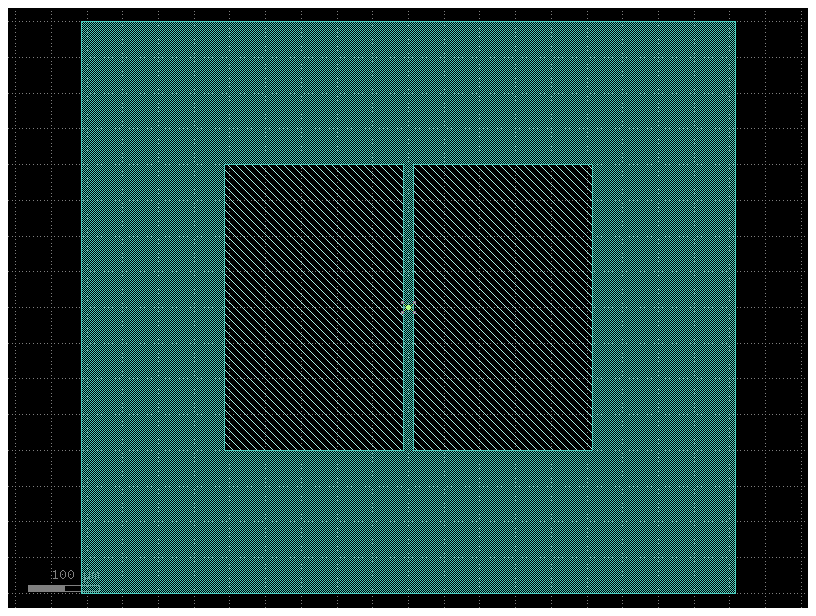

In [4]:
component.plot()

The `junction` port marks the centre of the SQUID; the `*_pad` ports are the
pad edges. None is a transmission-line port, so the extraction is asked for no
feed ports.

## Make an EM-only copy

`prepare_comsol_layout` rejects components carrying geometry on layers it does
not model, and the junction layers are among those. That rejection is
deliberate: silently dropping the mask would produce a model that looks right
and is wrong.

The simplification is explicit: record the junction position, then remove
`JJ_AREA` and `JJ_PATCH` from a copy of the cell. This omits the SQUID loop,
its superconducting leads, and their parasitic inductance and capacitance.
The pads and M1 etch mask remain. The missing junction branch must later be
replaced by a finite effective inductance at the recorded site; leaving the
pads isolated or shorting them gives a different eigenproblem.

In [5]:
junction_port = component.ports["junction"]
JUNCTION_CENTER_UM = tuple(junction_port.center)
JUNCTION_WIDTH_UM = junction_port.width
JUNCTION_ORIENTATION_DEG = junction_port.orientation

em_component = component.copy()
em_component.remove_layers(layers=[LAYER.JJ_AREA, LAYER.JJ_PATCH])

print(f"junction site: center={JUNCTION_CENTER_UM} µm")
print(f"  width={JUNCTION_WIDTH_UM} µm, orientation={JUNCTION_ORIENTATION_DEG}°")
print(f"layers kept:   {sorted(em_component.layers)}")
print("JJ_AREA/JJ_PATCH removed; M1_DRAW and M1_ETCH remain.")

junction site: center=(0.0, 0.0) µm
  width=33.446 µm, orientation=90.0°
layers kept:   [(1, 0), (1, 1)]
JJ_AREA/JJ_PATCH removed; M1_DRAW and M1_ETCH remain.


## Extract the COMSOL layout

With `feed_ports=None` the extractor returns metal polygons and a bounding
box, and an empty feed-port tuple.

In [6]:
layout = prepare_comsol_layout(em_component, feed_ports=None, ground_margin=100.0)

hole_count = sum(len(polygon.holes) for polygon in layout.polygons)
print(f"Metal polygons: {len(layout.polygons)} ({hole_count} holes total)")
print(f"Feed ports:     {layout.feed_ports}")
print(f"Prepared bbox (µm): {layout.bbox}")
print(f"  width = {layout.bbox.width:.3f} µm, height = {layout.bbox.height:.3f} µm")

Metal polygons: 3 (1 holes total)
Feed ports:     ()
Prepared bbox (µm): ComsolBoundingBox(xmin=-557.5, ymin=-500.0, xmax=557.5, ymax=500.0)
  width = 1115.000 µm, height = 1000.000 µm


### Holes are preserved

The etched moat is a *hole* in the ground-plane polygon; the pads are
separate metal polygons inside it. `ComsolPolygon` stores `outline` and
`holes` separately, and `build_comsol_metal_model` subtracts each hole.

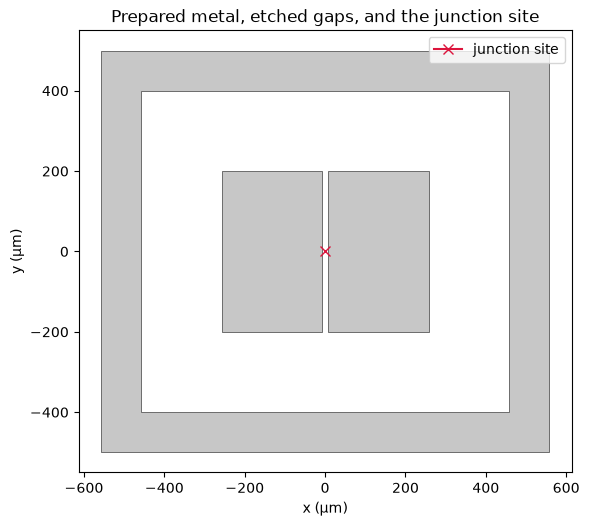

In [7]:
fig, ax = plt.subplots(figsize=(6, 6))
polygons_by_width = sorted(
    layout.polygons,
    key=lambda polygon: (
        max(x for x, _ in polygon.outline) - min(x for x, _ in polygon.outline)
    ),
    reverse=True,
)
for index, polygon in enumerate(polygons_by_width):
    shapes = [
        (polygon.outline, "0.78", 2 * index + 1),
        *((hole, "white", 2 * index + 2) for hole in polygon.holes),
    ]
    for points, facecolor, zorder in shapes:
        ax.add_patch(
            MplPolygon(
                points,
                closed=True,
                facecolor=facecolor,
                edgecolor="0.35",
                linewidth=0.6,
                zorder=zorder,
            )
        )
ax.plot(
    *JUNCTION_CENTER_UM,
    marker="x",
    color="crimson",
    markersize=7,
    zorder=2 * len(polygons_by_width) + 1,
    label="junction site",
)
ax.set_aspect("equal")
ax.set_xlabel("x (µm)")
ax.set_ylabel("y (µm)")
ax.set_title("Prepared metal, etched gaps, and the junction site")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## Build the COMSOL geometry project

`mph.start` launches a COMSOL server process and attaches to it. Only one MPh
client can exist per Python process, and the call needs a COMSOL installation
and a license. **The run is off by default** so the notebook executes while
building the documentation; set `RUN_COMSOL = True` on a licensed machine to
build and save the model.

The output path is outside the repository by default.

In [8]:
RUN_COMSOL = False
MODEL_DIR = Path.home() / "comsol_models"
MODEL_PATH = MODEL_DIR / "comsol_transmon_eigenmode.mph"
METAL_THICKNESS_UM = 0.2
CORES = 4

client = None
model = None

if not RUN_COMSOL:
    print(
        "RUN_COMSOL is False, so no COMSOL process was started. Set it to True "
        "on a machine with COMSOL and a license to build the geometry project."
    )
elif mph is None:
    print("MPh is not installed, so no COMSOL model was created.")
else:
    try:
        MODEL_DIR.mkdir(parents=True, exist_ok=True)
        client = mph.start(cores=CORES)
        model = build_comsol_metal_model(
            client,
            layout,
            metal_thickness_um=METAL_THICKNESS_UM,
            name="QPDK Double-Pad Transmon",
        )
        model.save(MODEL_PATH)
        print(f"Saved geometry project to {MODEL_PATH}")
    except Exception as error:  # COMSOL missing, not licensed, or busy
        print(f"COMSOL geometry build did not run: {error!r}")

RUN_COMSOL is False, so no COMSOL process was started. Set it to True on a machine with COMSOL and a license to build the geometry project.


### Inspect what the builder produced

At this point the model holds exactly one component, one 3D geometry with a
work plane and an extrude, and **no** physics, materials, mesh, or study.
`problems()` is the cheapest check that COMSOL itself is happy with the
geometry.

In [9]:
if model is not None:
    print(f"components: {model.components()}")
    print(f"geometries: {model.geometries()}")
    print(f"problems:   {model.problems()}")
    print(
        "Not yet present (by design): "
        f"physics={model.physics()}, materials={model.materials()}, "
        f"studies={model.studies()}"
    )
else:
    print("No model was built, so there is nothing to inspect.")

No model was built, so there is nothing to inspect.


## Continuing in the COMSOL GUI

The saved `.mph` opens directly in the COMSOL Desktop. The steps below turn it
into an eigenfrequency model. Do them in the GUI, where you can see the
selections, and make every selection on *this* geometry.

1. **Add the media**: a silicon block under the metal (typically 500 µm thick)
   and an air domain above and around it, large enough for the fields to decay
   before the boundary.
2. **Assign PEC** to the pad and ground faces, selected geometrically rather
   than by entity number.
3. **Add the Josephson inductance** at the junction site with a condition the
   RF Module supports for an eigenfrequency study, validated against a known
   result. Do not assume the frequency-domain `Inductor` preset carries over.
4. **Add an RF Electromagnetic Waves (emw) interface** on the dielectric and
   air domains, with PEC on the metal.
5. **Add an eigenfrequency study** searching a narrow band around the
   analytical estimate, and refine the mesh at the pad gap and the junction
   until the mode frequency stops moving.

Keep the metal as PEC for the first pass; a surface impedance or transition
boundary using the superconductor's surface resistance and kinetic inductance
is a later step that shifts the frequency.

## Solve or inspect a configured model with MPh

Save the GUI-configured model to `CONFIGURED_MODEL_PATH`. Set `RUN_COMSOL = True`
above to connect, then set `RUN_SOLVE = True` below to run its named study and
save the solution separately. With `RUN_SOLVE = False`, this cell can inspect
results already stored in the configured file. **Any eigenfrequency printed
here is a solver output only if that model contains a real solution.**

In [10]:
CONFIGURED_MODEL_PATH = MODEL_DIR / "comsol_transmon_eigenmode_configured.mph"
SOLVED_MODEL_PATH = MODEL_DIR / "comsol_transmon_eigenmode_solved.mph"
RUN_SOLVE = False
STUDY_NAME = "Study 1"
EIGENMODE_DATASET_NAME = None

eigenfrequencies_ghz = None

if not RUN_COMSOL:
    print("COMSOL solve and result inspection are disabled by RUN_COMSOL.")
elif not CONFIGURED_MODEL_PATH.exists():
    print(f"No configured model named {CONFIGURED_MODEL_PATH.name!r} in MODEL_DIR")
    print(
        "Continue the geometry project in COMSOL, add the eigenfrequency study, "
        "save it there, then re-run this cell."
    )
elif mph is None:
    print("Install MPh and connect to COMSOL to inspect the configured model.")
else:
    if client is None:
        client = mph.start(cores=CORES)
    solved_model = client.load(CONFIGURED_MODEL_PATH)
    studies = solved_model.studies()
    print(f"studies:  {studies}")
    if RUN_SOLVE:
        if STUDY_NAME not in studies:
            raise ValueError(f"Study {STUDY_NAME!r} is not in this model: {studies}")
        solved_model.solve(STUDY_NAME)
        solved_model.save(SOLVED_MODEL_PATH)
        print(f"Saved solved model as {SOLVED_MODEL_PATH.name}")
    datasets = solved_model.datasets()
    print(f"datasets: {datasets}")
    if EIGENMODE_DATASET_NAME is None:
        print("Set EIGENMODE_DATASET_NAME to the eigenfrequency study's dataset.")
    elif EIGENMODE_DATASET_NAME not in datasets:
        print(f"Dataset {EIGENMODE_DATASET_NAME!r} is not in this model: {datasets}")
    else:
        try:
            eigenfrequencies_ghz = (
                solved_model.evaluate("freq", dataset=EIGENMODE_DATASET_NAME) / 1e9
            )
        except Exception as error:
            print(f"No 'freq' solution on this dataset: {error!r}")
        else:
            print(f"Eigenfrequencies (GHz) = {eigenfrequencies_ghz}")

if eigenfrequencies_ghz is None:
    print("No solved eigenfrequency data, so none is reported.")

COMSOL solve and result inspection are disabled by RUN_COMSOL.
No solved eigenfrequency data, so none is reported.


Select a dataset belonging to the eigenfrequency study, not a driven sweep:
both can define `freq`, but only the former contains eigenmodes. If your
study stores eigenvalues under another expression, check Results in the GUI.

## Summary

This notebook built the QPDK `double_pad_transmon_with_bbox` cell, made an
EM-only copy with the `JJ_AREA`/`JJ_PATCH` lead and SQUID geometry removed,
and extracted the pad metal, the preserved
etched holes, and the junction site with
`prepare_comsol_layout(..., feed_ports=None)`. It then described how to build,
save, and inspect an **unsolved** geometry project with
`build_comsol_metal_model` (`RUN_COMSOL = True` on a licensed machine) and the
physics a linearized transmon eigenmode needs: substrate and air, PEC, correct
boundary selections, a finite Josephson inductance at the junction, and an RF
eigenfrequency study. It noted that the frequency-domain `Inductor` preset is
not documented for eigenfrequency and that a user-defined impedance would need
validating, and showed how to load a configured model, optionally run its
study, and inspect datasets and eigenfrequencies.

What it did **not** do: add physics, materials, an inductance, a mesh, or a
study, or compute an eigenfrequency.

**Recommended next steps:**

- Feed the linearized mode into the QPDK Hamiltonian workflow
  ({doc}`/notebooks/scqubits_parameter_calculation`) to get $f_{01}$, $f_{12}$,
  and the anharmonicity, rather than reading them off the EM solve.
- Compare the EM mode with the analytical transmon estimate from $E_J$ and
  $E_C$; a large discrepancy usually means the inductance or the junction
  coupling was set up incorrectly.

## References

```{bibliography}
:filter: docname in docnames
```